In [38]:
suppressPackageStartupMessages(library(SingleCellExperiment))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(argparse))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(scran))

######################
## Define arguments ##
######################

# p <- ArgumentParser(description='')
# p$add_argument('--sce',             type="character",                               help='SingleCellExperiment file')
# p$add_argument('--metadata',        type="character",                               help='Cell metadata file')
# p$add_argument('--stage',           type="character",                               help='Stages to include')
# p$add_argument('--tdTom_corr',      type="character",                                 help='Keep tdTom+ cells in WT samples (otherwise removed)')
#p$add_argument('--method',          type="character",                               help='Method to use for DEGs, options: singlecell, pseudobulk, pseudobulkreplicates (pseudobulk with replicates from within each sample)')
# p$add_argument('--outdir',          type="character",                               help='Output file')

# args <- p$parse_args(commandArgs(TRUE))

#####################
## Define settings ##
#####################
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))
source(here::here("mapping/run/mnn/mapping_functions.R"))
test = TRUE

if(test){
## START TEST ##
    args = list()
args$sce <- io$rna.sce
args$metadata <- io$metadata
args$stage <- c('E6.5')#, 'E8.5', 'E9.5')
args$variable = 'celltype.mapped_mnn'
args$metadata <- paste0(io$basedir,"/results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$tdTom_corr = 'False'
args$method = 'singlecell'
args$outdir <- paste0(io$basedir,"/results/rna/differential/test")
## END TEST ##
}

# If passing multiple timepoints split in vector
args$stage = strsplit(args$stage, "_")[[1]] 

dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/13_Axin1_2/code



In [26]:

# Plotting function
gg_volcano_plot <- function(celltype_i='Allantois', top_genes=20, xlim=5, ylim=40, label_groups = NULL) {
  to.plot = de.results[variable == celltype_i]
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot[!is.na(sig)])
  to.plot = to.plot[,logFC_plot:=ifelse(logFC<=-xlim, -xlim, ifelse(logFC>=xlim, xlim, logFC))] %>%
               .[,log10_padj_fdr:=ifelse(-log10(padj_fdr)>=ylim, ylim, -log10(padj_fdr))]
  
  # if (is.null(xlim))
  #   xlim <- max(abs(to.plot$logFC), na.rm=T)
  # if (is.null(ylim))
  #   ylim <- max(-log10(to.plot$padj_fdr+1e-100), na.rm=T)
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)] %>% .[order(-abs(logFC))]
  label_genes = c(head(to.plot[sig==T & logFC<=0, gene],n=top_genes), head(to.plot[sig==T & logFC>=0, gene],n=top_genes))
  
  p <- ggplot(to.plot, aes(x=logFC_plot, y=log10_padj_fdr)) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=ylim*1.05), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-xlim,xlim)) +
    scale_y_continuous(limits=c(0,ylim*1.16)) +
    annotate("text", x=0, y=ylim*1.1, size=6, label=sprintf("(%d)", all)) +
    annotate("text", x=-xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=to.plot[gene %in% label_genes],
                                    aes(x=logFC_plot, y=log10_padj_fdr, label=gene), 
                                     max.overlaps=Inf, 
                                     box.padding = 0.5,
                                     bg.color='white', 
                                     bg.r = 0.1,
                                     size=5) +
    theme_classic() +
    theme(
       axis.text = element_text(color='black'),
      # axis.title = element_text(size=rel(1.0), color='black'),
      text=element_text(size=15),
      legend.position="none"
    ) + 
    ggtitle(celltype_i)
    
    
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(p)
}

# Single cell DEG function

doDiffExpr <- function(sce, groups, min_detection_rate_per_group = 0.35) {
    
  # Sanity checks
  if (!is(sce, "SingleCellExperiment")) stop("'sce' has to be an instance of SingleCellExperiment")
  stopifnot(length(groups)==2)

  # Filter genes by detection rate per group
  cdr_A <- rowMeans(counts(sce[,sce$tdTom_corr==groups[1]])>0) >= min_detection_rate_per_group
  cdr_B <- rowMeans(counts(sce[,sce$tdTom_corr==groups[2]])>0) >= min_detection_rate_per_group
  out <- .edgeR(sce[cdr_B | cdr_A,]) %>% .[,log_padj_fdr:= -log10(padj_fdr)]
  
  return(out)
}


.edgeR <- function(sce) {
  
  # Convert SCE to DGEList
  
  sce_edger <- scran::convertTo(sce, type="edgeR")
  # sce_edger$samples$norm.factors = sce_edger$samples$sizeFactor
    
  # Define design matrix (with intercept)
  #cdr <- colMeans(logcounts(sce)>0)
  # if overlap in pools between KO and WT, use pool in model
  # Should I even run this if there's no overlap in pool? or just always use without pool?
  meta = as.data.table(colData(sce))
  if(length(intersect(unique(meta[tdTom_corr==TRUE,pool]), unique(meta[tdTom_corr==FALSE,pool])))>0 & length(unique(meta$pool))>1){
            
      # Calculate norm factors
      sce_edger <- calcNormFactors(sce_edger)
      
      design <- model.matrix(~sce$pool+sce$tdTom_corr)

      # Estimate dispersions
      sce_edger  <- estimateDisp(sce_edger,design)
    
      # Fit GLM
      fit <- glmQLFit(sce_edger,design)

      # Likelihood ratio test
      lrt <- glmQLFTest(fit)

      # Construct output data.frame
      out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
        setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
        .[,c("logCPM","LR"):=NULL]  
  }else{
      out = data.table("gene" = NA, "logFC" = NA, "p.value" = NA, "padj_fdr" = NA)
  }
  
  return(out)
}


In [39]:

##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
   .[pass_rnaQC==TRUE & doublet_call==FALSE & stage %in% args$stage] %>%
   .[,pool:=stringr::str_replace_all(sample,opts$sample2pool)] %>% 
   .[,variable := .[[args$variable]]]

# discard Tomato+ cells from Tomato- samples
if(args$tdTom_corr!='True'){
    sample_metadata = sample_metadata[tdTom==tdTom_corr]
}

In [30]:
# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

In [31]:
gene_biomart = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.87.txt')
all_genes = gene_biomart$symbol

# Genes on the y-chr can be differential due to the injected ESC being male, while the host can be either male or female
y_genes = gene_biomart[chr=='chrY', symbol]

# Some genes on the x-chr can be differential for the same reason
# Xist and Tsix are known to often be differentially expressed 
x_genes = c('Xist', 'Tsix')

# Additionally there are some paternally or maternally expressed genes to remove
imprint = gene_biomart[c(grep('maternally', gene_biomart$description),
                       grep('paternally', gene_biomart$description)), symbol]
imprint = c(imprint, 'Grb10', 'Nnat')

# Remove all other genes that are not informative, e.g. mitochondrial/ribosomal/predicted genes etc
non_informative = all_genes[grep("*Rik|^Gm|^mt-|^Rps|^Rpl|^Olfr", all_genes)]

# Genes differential from WT injection experiment
#WT_inj = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/old/tomato_DEGs_edgeR.csv')

# Tomato-td is differentially expressed, because it is only present in the KO cells
excl_genes = intersect(c(y_genes, x_genes, imprint, non_informative), rownames(sce))


sce = sce[!rownames(sce) %in% excl_genes,]

In [33]:
unique(sample_metadata$celltype.mapped_mnn)

[1] "Mixed_mesoderm"                 "ExE_endoderm"                  
 [3] "Mesenchyme"                     "ExE_ectoderm"                  
 [5] "Haematoendothelial_progenitors" "Visceral_endoderm"             
 [7] "Nascent_mesoderm"               "PGC"                           
 [9] "Primitive_Streak"               "Parietal_endoderm"             
[11] "Surface_ectoderm"               "Epiblast"                      
[13] "ExE_mesoderm"                   "Blood_progenitors_1"           
[15] "Blood_progenitors_2"            "Anterior_Primitive_Streak"     
[17] "Def._endoderm"

In [36]:
sce_deg

class: SingleCellExperiment 
dim: 19344 0 
metadata(0):
assays(2): counts logcounts
rownames(19344): Xkr4 Rp1 ... Vmn2r122 CAAA01147332.1
rowData names(0):
colnames(0):
colData names(22): sample barcode ... pool variable
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [43]:
    opts$groups = c(FALSE, TRUE)


In [44]:
x = 'ExE_ectoderm' 
            message(x)
            sce_deg = sce[, sample_metadata$variable==x]
                out <- doDiffExpr(sce_deg, opts$groups) %>%
                  # Add sample statistics
                  .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
                  .[,c("groupA","groupB", "variable"):=list(opts$groups[1],opts$groups[2],x)]%>%  
                  # Calculate statistical significance
                  .[, sig := (padj_fdr<=0.05 & abs(logFC)>=1)] %>%
                  .[is.na(sig),sig:=FALSE] %>% 
                  setorder(-sig, padj_fdr, na.last=T) %>%
                  # Add celltype
                    .[,variable:=x]

                # Parse columns
                out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]
                return(out)

ExE_ectoderm



gene,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,variable,sig
<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<lgl>,<lgl>,<chr>,<lgl>
NA,NA,NA,NA,NA,NA,NA,FALSE,TRUE,ExE_ectoderm,FALSE


In [ ]:
    library(parallel)
    if(detectCores() >1){
        cores = detectCores()-1
    }else{
        cores = 1
    }
        
    sce$group = sample_metadata$tdTom_corr
    opts$groups = c(FALSE, TRUE)
    sce$group = factor(sce$group, levels = opts$groups)
        
    de.results = mclapply(unique(sample_metadata$variable), function(x){     #unique(meta$celltype.mapped)
        # Only keep cell types with at least 20 cells in both KO and WT
        if(!TRUE %in% as.vector(as.data.frame(table(sample_metadata[variable==x, tdTom_corr]))$Freq<20) & 
           length(unique(sample_metadata[variable==x, tdTom_corr]))==2){
            message(x)
            sce_deg = sce[, sample_metadata$variable==x]
                out <- doDiffExpr(sce_deg, opts$groups) %>%
                  # Add sample statistics
                  .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
                  .[,c("groupA","groupB", "variable"):=list(opts$groups[1],opts$groups[2],x)]%>%  
                  # Calculate statistical significance
                  .[, sig := (padj_fdr<=0.05 & abs(logFC)>=1)] %>%
                  .[is.na(sig),sig:=FALSE] %>% 
                  setorder(-sig, padj_fdr, na.last=T) %>%
                  # Add celltype
                    .[,variable:=x]

                # Parse columns
                out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]
                return(out)
                } 
            }, mc.cores=cores) %>% rbindlist()
    
    # Make plots
    plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=100, xlim=5)

In [50]:
groups

function (x) 
{
    UseMethod("groups")
}
<bytecode: 0x55a636f4cc38>
<environment: namespace:dplyr>

In [51]:
            sce_deg = sce[, sample_metadata$variable==x]
min_detection_rate_per_group = 0.35
cdr_A <- rowMeans(counts(sce_deg[,sce_deg$tdTom_corr== opts$groups[1]])>0) >= min_detection_rate_per_group
  cdr_B <- rowMeans(counts(sce_deg[,sce_deg$tdTom_corr== opts$groups[2]])>0) >= min_detection_rate_per_group

In [54]:
summary(cdr_A)
summary(cdr_B)

   Mode   FALSE    TRUE 
logical   14441    4903 

   Mode   FALSE    TRUE 
logical   13000    6344 

In [55]:
sce_deg[cdr_B | cdr_A,]

class: SingleCellExperiment 
dim: 6351 1345 
metadata(0):
assays(2): counts logcounts
rownames(6351): Mrpl15 Lypla1 ... Vamp7 PISD
rowData names(0):
colnames(1345): LibA_DKOAxin1Axin2_E6_1_IGO_14590_1#AAACGAACAGTTGGTT-1
  LibA_DKOAxin1Axin2_E6_1_IGO_14590_1#AAACGCTTCCGCGATG-1 ...
  LibB_WT_E6_1_IGO_14590_2#TTTGTTGAGGAGGTTC-1
  LibB_WT_E6_1_IGO_14590_2#TTTGTTGTCTAACGCA-1
colData names(22): sample barcode ... pool variable
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [56]:
out <- .edgeR(sce_deg[cdr_B | cdr_A,])

In [58]:
  sce_edger <- scran::convertTo(sce_deg[cdr_B | cdr_A,], type="edgeR")


In [59]:
  meta = as.data.table(colData(sce_deg))


In [64]:
      sce_edger <- calcNormFactors(sce_edger)
      
      design <- model.matrix(~sce_deg$tdTom_corr)

In [66]:
      # Estimate dispersions
      sce_edger  <- estimateDisp(sce_edger,design)
    
      # Fit GLM
      fit <- glmQLFit(sce_edger,design)

      # Likelihood ratio test
      lrt <- glmQLFTest(fit)

      # Construct output data.frame
      out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
        setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
        .[,c("logCPM","LR"):=NULL]  

In [74]:
de.results = out[, variable:='Allantois'] %>% 
    .[, sig := (padj_fdr<=0.05 & abs(logFC)>=1)] %>%
                  .[is.na(sig),sig:=FALSE] %>% 
                  setorder(-sig, padj_fdr, na.last=T)

In [77]:
tail(de.results)

gene,logFC,p.value,padj_fdr,variable,sig
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
Phc2,-4.361982e-04,0.9953614,0.9961456,Allantois,FALSE
Nr1h5,-1.377976e-03,0.9959886,0.9966163,Allantois,FALSE
Jtb,7.888711e-04,0.9974154,0.9978867,Allantois,FALSE
Cenpb,1.141996e-04,0.9979402,0.9982546,Allantois,FALSE
Lamtor4,3.191017e-05,0.9988766,0.9990339,Allantois,FALSE
Ube2n,1.179166e-04,0.9998062,0.9998062,Allantois,FALSE


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


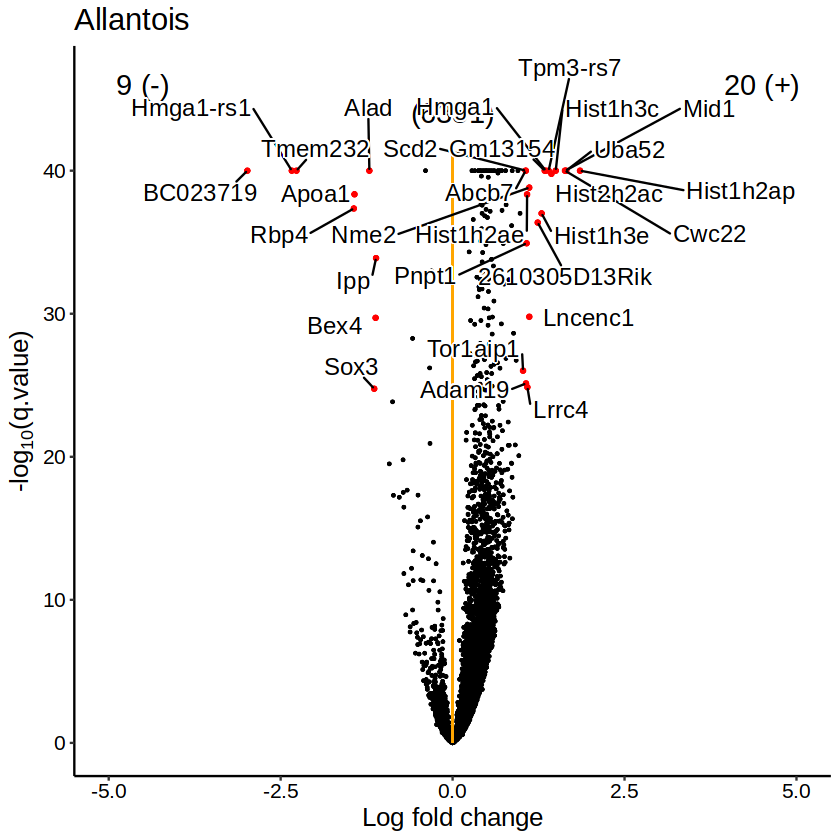

In [76]:
gg_volcano_plot()

In [ ]:
  # sce_edger$samples$norm.factors = sce_edger$samples$sizeFactor
    
  # Define design matrix (with intercept)
  #cdr <- colMeans(logcounts(sce)>0)
  # if overlap in pools between KO and WT, use pool in model
  # Should I even run this if there's no overlap in pool? or just always use without pool?
  if(length(intersect(unique(meta[tdTom_corr==TRUE,pool]), unique(meta[tdTom_corr==FALSE,pool])))>0 & length(unique(meta$pool))>1){
            
      # Calculate norm factors
      sce_edger <- calcNormFactors(sce_edger)
      
      design <- model.matrix(~sce$pool+sce$tdTom_corr)

      # Estimate dispersions
      sce_edger  <- estimateDisp(sce_edger,design)
    
      # Fit GLM
      fit <- glmQLFit(sce_edger,design)

      # Likelihood ratio test
      lrt <- glmQLFTest(fit)

      # Construct output data.frame
      out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
        setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
        .[,c("logCPM","LR"):=NULL]  

In [57]:
out

gene,logFC,p.value,padj_fdr
<lgl>,<lgl>,<lgl>,<lgl>
NA,NA,NA,NA


In [ ]:
out <- doDiffExpr(sce_deg, opts$groups)